In [2]:
import os
import sys
sys.path.insert(0, '..')

import json
import pandas as pd
from collections import Counter  
import matplotlib.pyplot as plt  
import seaborn as sns
from itertools import combinations
import jieba
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2, mutual_info_classif
from data import load_json

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Zen Hei', 'Noto Sans CJK SC'] 
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False 
HATE_GROUPS = {"LGBTQ", "Region", "Sexism", "Racism", "others", "non-hate"}
HATEFUL_LABELS = {"hate", "non-hate"}
SEP_TOKEN = "[SEP]"
END_TOKEN = "[END]"
FONT_PATH = "C:/Windows/Fonts/simhei.ttf" if os.path.exists("C:/Windows/Fonts/simhei.ttf") else '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

/root/miniconda3/envs/llmtoxi/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Dataset saved to train_output.json
Dataset saved to test_output.json


In [3]:
train_data = load_json("../data/train_output.json")
test_data = load_json("../data/test_output.json")
print(f'训练样本数: {len(train_data)}')
print(f'测试样本数: {len(test_data)}')

FileNotFoundError: [Errno 2] No such file or directory: '../data/train_output.json'

In [ ]:
hate_counts = Counter(s['sen_hate'] for s in train_data)
print('训练集仇恨分布:', dict(hate_counts))
group_counts = {group: 0 for group in HATE_GROUPS}
for record in train_data:
    output = record.get('output', '')
    for group in HATE_GROUPS:
        if group in output:
            group_counts[group] += 1
print('HATE_GROUPS 出现次数:\n', group_counts)


训练集仇恨分布: {0: 2483, 1: 3941}
HATE_GROUPS 出现次数:
 {'non-hate': 2552, 'LGBTQ': 506, 'others': 399, 'Sexism': 1550, 'Region': 976, 'Racism': 1247}


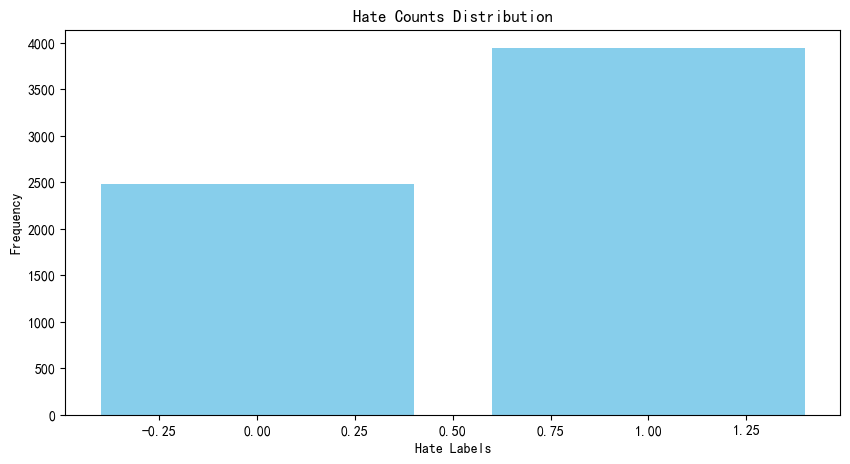

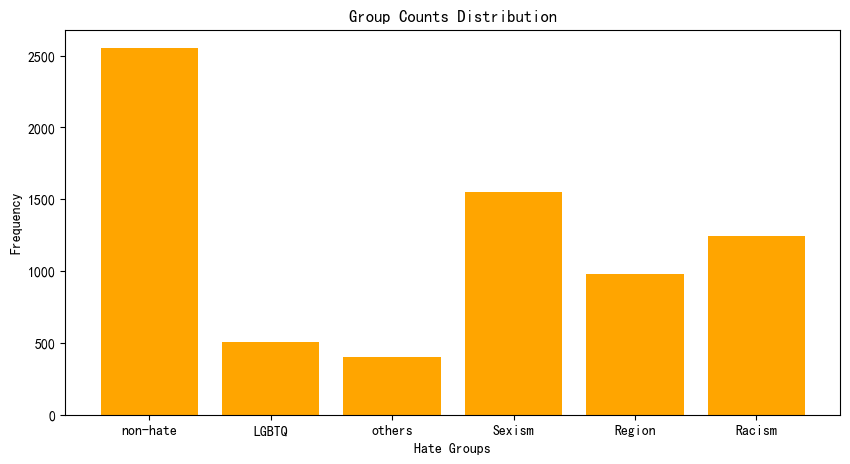

In [ ]:

# 绘制 hate_counts 柱状图
plt.figure(figsize=(10, 5))
plt.bar(hate_counts.keys(), hate_counts.values(), color='skyblue')
plt.title('Hate Counts Distribution')
plt.xlabel('Hate Labels')
plt.ylabel('Frequency')
plt.show()

# 绘制 group_counts 柱状图
plt.figure(figsize=(10, 5))
plt.bar(group_counts.keys(), group_counts.values(), color='orange')
plt.title('Group Counts Distribution')
plt.xlabel('Hate Groups')
plt.ylabel('Frequency')
plt.show()

In [ ]:
topic_counts = Counter(s['topic'] for s in train_data)
print('主题分布:', dict(topic_counts))

主题分布: {'race': 2505, 'region': 1395, 'gender': 1458, 'lgbt': 1066}


In [ ]:
from collections import defaultdict

# --- 目标群体与论点关键词共现 ---
group_arg_rows = []
combo_stats = defaultdict(lambda: {"count": 0, "hate": 0})
for sample in train_data:
    for quad in sample.get("quadruples", []):
        argument = str(quad.get("argument", "")).strip()
        if not argument:
            continue
        tokenized = " ".join(jieba.lcut(argument))
        groups_raw = [g.strip() for g in str(quad.get("group", "")).split(",") if g.strip()]
        if not groups_raw:
            groups_raw = ["others"]
        hateful_flag = str(quad.get("hateful", "non-hate")).lower() == "hate"
        for g in groups_raw:
            group_arg_rows.append(
                {
                    "group": g,
                    "argument": argument,
                    "argument_tokens": tokenized,
                    "hateful": quad.get("hateful", "non-hate")
                }
            )
        unique_groups = sorted(set(groups_raw))
        if len(unique_groups) >= 2:
            for r in range(2, len(unique_groups) + 1):
                for combo in combinations(unique_groups, r):
                    combo_stats[combo]["count"] += 1
                    if hateful_flag:
                        combo_stats[combo]["hate"] += 1


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\okkb\AppData\Local\Temp\jieba.cache
Loading model cost 0.584 seconds.
Prefix dict has been built successfully.


In [ ]:
group_arg_rows

[{'group': 'non-hate',
  'argument': '坦白吧，放过人家',
  'argument_tokens': '坦白 吧 ， 放过 人家',
  'hateful': 'non-hate'},
 {'group': 'Sexism',
  'argument': '国女又看不上',
  'argument_tokens': '国女 又 看不上',
  'hateful': 'hate'},
 {'group': 'Sexism',
  'argument': '在部分国女眼里早就被开除人籍了',
  'argument_tokens': '在 部分 国女 眼里 早就 被 开除 人籍 了',
  'hateful': 'hate'},
 {'group': 'Racism',
  'argument': '才是人上人',
  'argument_tokens': '才 是 人 上 人',
  'hateful': 'hate'},
 {'group': 'non-hate',
  'argument': '当地人都挺好的',
  'argument_tokens': '当地人 都 挺 好 的',
  'hateful': 'non-hate'},
 {'group': 'non-hate',
  'argument': '没必要这么敏感',
  'argument_tokens': '没 必要 这么 敏感',
  'hateful': 'non-hate'},
 {'group': 'Sexism',
  'argument': '铁鲨鼻',
  'argument_tokens': '铁 鲨 鼻',
  'hateful': 'hate'},
 {'group': 'LGBTQ',
  'argument': '高贵',
  'argument_tokens': '高贵',
  'hateful': 'hate'},
 {'group': 'Sexism',
  'argument': '居然没有一个拳师冲',
  'argument_tokens': '居然 没有 一个 拳师 冲',
  'hateful': 'hate'},
 {'group': 'Racism',
  'argument': '征尼大将军',
  'argumen

In [ ]:

df_group_arg = pd.DataFrame(group_arg_rows)
print(f"共收集 group-argument 配对 {len(df_group_arg)} 条。")
if df_group_arg.empty:
    raise ValueError("未找到可以分析的四元组 argument 数据。")


共收集 group-argument 配对 8359 条。


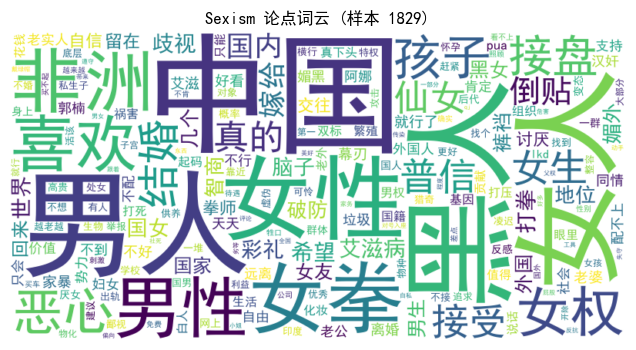

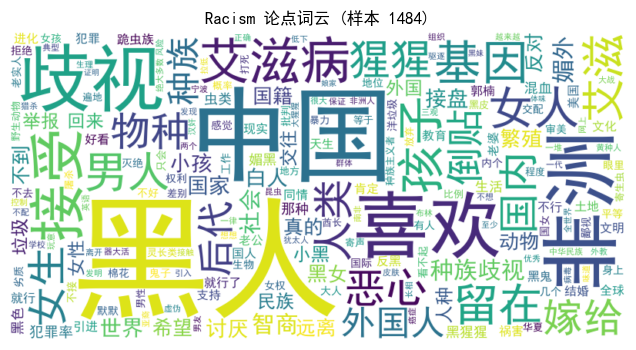

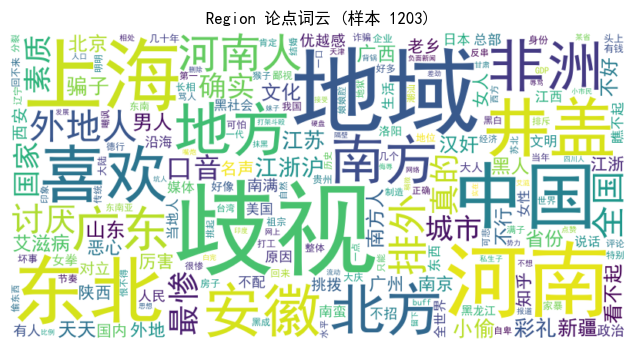

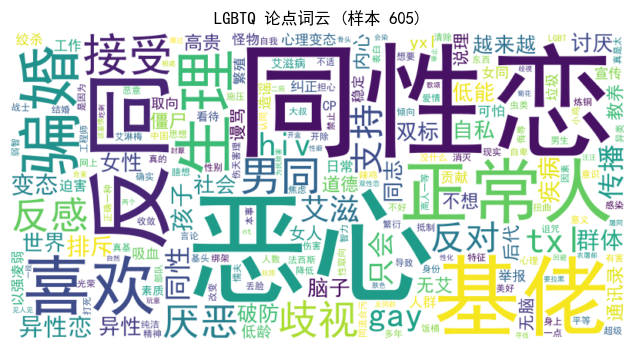

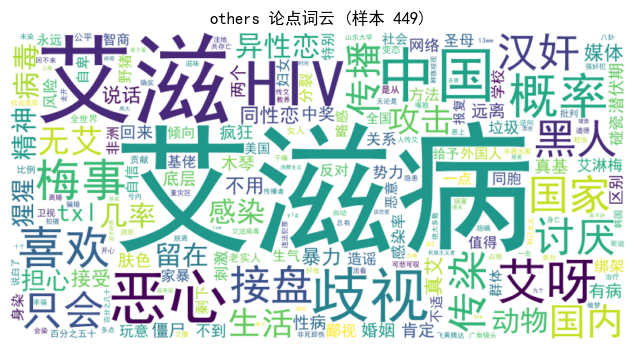

In [ ]:
import re
# 生成每个 group 的词云（取样本最多的前 6 个群体）
group_freq = df_group_arg["group"].value_counts()
top_groups = group_freq.head(6).index
for group in top_groups:
    if group == "non-hate":
        continue
    text = " ".join(df_group_arg.loc[df_group_arg["group"] == group, "argument_tokens"])
    text = re.sub(r'[^\w\s]', '', text)

    # 中文分词
    words = jieba.lcut(text)

    # 加载停用词表
    stopwords = set([line.strip() for line in open('../data/stop_words.txt', encoding='utf-8')])
    filtered_words = [w for w in words if w not in stopwords and len(w) > 1]

    # 合并为字符串
    cleaned_text = ' '.join(filtered_words)
    if not text.strip():
        continue
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        font_path=FONT_PATH,
        collocations=False,
    ).generate(cleaned_text)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{group} 论点词云 (样本 {group_freq[group]})")
    plt.show()


In [ ]:

# 计算关键词的互信息 / 卡方值
vectorizer = CountVectorizer(token_pattern=r"[^ ]+", ngram_range=(1, 2), min_df=5)
X = vectorizer.fit_transform(df_group_arg["argument_tokens"])
feature_names = vectorizer.get_feature_names_out()
group_keyword_stats = {}
for group in top_groups:
    y = (df_group_arg["group"] == group).astype(int)
    if y.sum() < 5 or y.sum() == len(y):
        continue
    chi2_scores, _ = chi2(X, y)
    mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
    top_idx = chi2_scores.argsort()[::-1][:15]
    group_keyword_stats[group] = [
        (feature_names[i], float(chi2_scores[i]), float(mi_scores[i]))
        for i in top_idx
    ]

for group, items in group_keyword_stats.items():
    print(f"\n{group} 特征关键词 (chi2, MI):")
    for token, chi_score, mi_score in items:
        print(f"  {token}: chi2={chi_score:.3f}, MI={mi_score:.3f}")



non-hate 特征关键词 (chi2, MI):
  ，: chi2=94.324, MI=0.005
  黑人: chi2=91.001, MI=0.007
  黑: chi2=73.795, MI=0.005
  非洲: chi2=46.016, MI=0.004
  中国: chi2=42.816, MI=0.003
  艾滋: chi2=31.545, MI=0.003
  找: chi2=30.220, MI=0.002
  恶心: chi2=26.556, MI=0.002
  艾滋病: chi2=23.123, MI=0.002
  被: chi2=22.982, MI=0.001
  歧视: chi2=22.599, MI=0.002
  女人: chi2=20.281, MI=0.001
  舔: chi2=20.029, MI=0.002
  男: chi2=18.427, MI=0.001
  挺 好: chi2=18.346, MI=0.001

Sexism 特征关键词 (chi2, MI):
  女拳: chi2=95.620, MI=0.004
  女人: chi2=85.282, MI=0.004
  男人: chi2=79.748, MI=0.004
  舔: chi2=79.047, MI=0.004
  男: chi2=75.645, MI=0.004
  女: chi2=72.259, MI=0.003
  女性: chi2=69.679, MI=0.004
  男性: chi2=66.299, MI=0.003
  她: chi2=65.386, MI=0.003
  舔 狗: chi2=60.694, MI=0.003
  仙女: chi2=47.284, MI=0.002
  普信: chi2=47.284, MI=0.002
  狗: chi2=46.084, MI=0.002
  男 的: chi2=42.244, MI=0.002
  女权: chi2=41.378, MI=0.002

Racism 特征关键词 (chi2, MI):
  黑人: chi2=446.078, MI=0.019
  中国: chi2=73.549, MI=0.003
  非洲: chi2=68.704, MI=0.003
  

In [ ]:

# --- 多群体共现统计 ---
combo_rows = []
for combo, stats in combo_stats.items():
    if stats["count"] == 0:
        continue
    combo_rows.append(
        {
            "groups": " & ".join(combo),
            "count": stats["count"],
            "hate_rate": stats["hate"] / stats["count"]
        }
    )
combo_df = pd.DataFrame(combo_rows).sort_values(by="count", ascending=False)
print("\n多群体共现（按频次排序）:")
print(combo_df.head(10))



多群体共现（按频次排序）:
                      groups  count  hate_rate
0            Racism & Sexism    407   0.997543
1            Region & Sexism     77   1.000000
4            Racism & others     67   1.000000
3            Racism & Region     55   1.000000
2             LGBTQ & others     54   1.000000
10           Sexism & others     49   1.000000
9             LGBTQ & Sexism     24   1.000000
5            Region & others     22   0.954545
12  Racism & Sexism & others     17   1.000000
7   Racism & Region & Sexism     12   1.000000


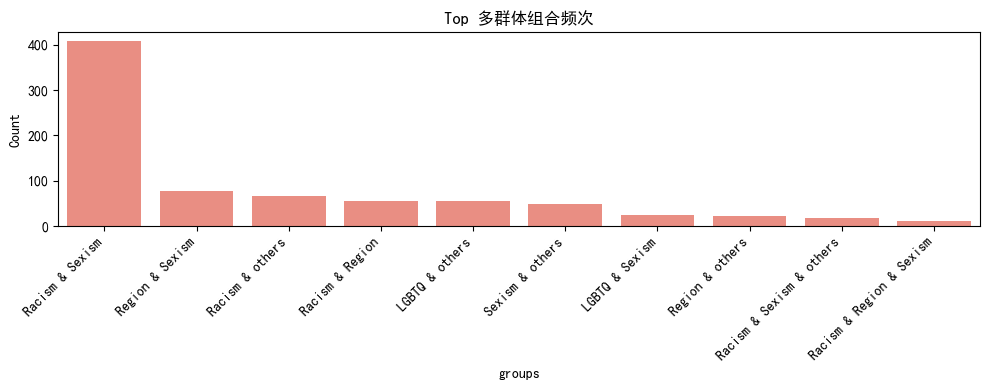

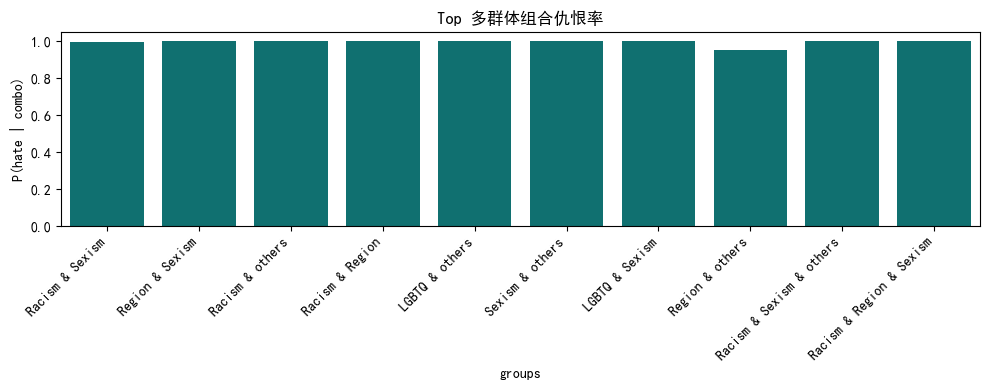

In [ ]:

if not combo_df.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=combo_df.head(10), x="groups", y="count", color="salmon")
    plt.xticks(rotation=45, ha="right")
    plt.title("Top 多群体组合频次")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.barplot(data=combo_df.head(10), x="groups", y="hate_rate", color="teal")
    plt.xticks(rotation=45, ha="right")
    plt.title("Top 多群体组合仇恨率")
    plt.ylabel("P(hate | combo)")
    plt.tight_layout()
    plt.show()
else:
    print("没有检测到多群体共现。")